# Fase 1 — Exploración de bases de datos
**Grupo 3 · Evento Evaluativo 2 · Análisis de Datos**
Integrantes: Santiago Betancur, Diego Alzate, Carlos Mendez, Sebastian Cadavid, Daniel Martinez

Objetivo: explorar al menos 3 bases de datos de al menos 2 tipos diferentes, documentar sus características y justificar con criterios objetivos cuál se usará en las Fases 2 y 3.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (8, 4)

## 1.1 Dataset A — Titanic (datos **tabulares**)

**Fuente:** compilación histórica de los pasajeros del RMS Titanic (1912), distribuida públicamente por Kaggle / Vanderbilt University y cargada aquí vía la librería `seaborn`.
**Tipo de fuente:** **secundaria** — no fue recolectada directamente por nosotros, sino reconstruida y documentada por terceros a partir de registros históricos (listas de pasajeros, manifiestos de la naviera).

In [2]:
titanic = sns.load_dataset('titanic')
print('Registros:', titanic.shape[0])
print('Atributos:', titanic.shape[1])
print('Tamaño en memoria (KB):', round(titanic.memory_usage(deep=True).sum()/1024, 1))
titanic.head()

Registros: 891
Atributos: 15
Tamaño en memoria (KB): 278.9


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


**Documentación disponible:** alta — es uno de los datasets más documentados y usados para aprender ciencia de datos (diccionario de variables ampliamente conocido: `Pclass`, `Sex`, `Age`, `Fare`, `Survived`, etc.).
**Posibles aplicaciones:** clasificación (predecir supervivencia), análisis de factores socioeconómicos y demográficos en una tragedia histórica, práctica de limpieza de datos (tiene valores faltantes reales en `age`, `deck`, `embarked`).

## 1.2 Dataset B — Optical Digits (datos de **imágenes**)

**Fuente:** conjunto "Optical Recognition of Handwritten Digits", originalmente recolectado por E. Alpaydin y C. Kaybaşı (Bogazici University) y distribuido por el UCI Machine Learning Repository; se carga aquí desde `scikit-learn`.
**Tipo de fuente:** **secundaria** — dataset ya procesado y normalizado (imágenes de 8x8 píxeles) a partir de escaneos originales de dígitos escritos a mano.

Registros (imágenes): 1797
Dimensión de cada imagen: (8, 8) -> aplanada a 64 atributos (píxeles)
Tamaño en memoria (KB): 898.5


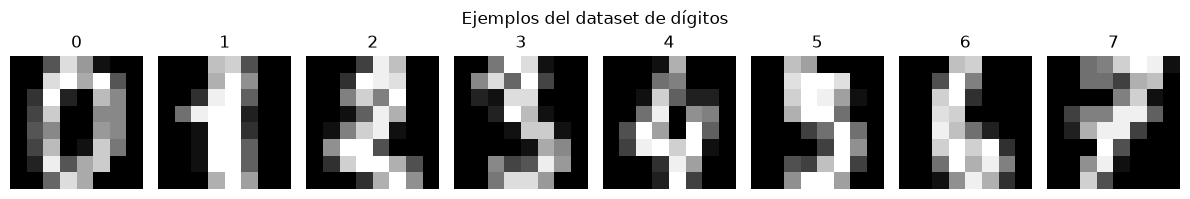

In [4]:
digits = load_digits()
print('Registros (imágenes):', digits.images.shape[0])
print('Dimensión de cada imagen:', digits.images.shape[1:], '-> aplanada a', digits.data.shape[1], 'atributos (píxeles)')
print('Tamaño en memoria (KB):', round(digits.data.nbytes/1024, 1))

fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for ax, img, label in zip(axes, digits.images[:8], digits.target[:8]):
    ax.imshow(img, cmap='gray')
    ax.set_title(str(label))
    ax.axis('off')
plt.suptitle('Ejemplos del dataset de dígitos')
plt.tight_layout()
plt.show()

**Documentación disponible:** alta — dataset de referencia en UCI/sklearn, con descripción oficial y uso extendido en la literatura de reconocimiento de patrones.
**Posibles aplicaciones:** clasificación de imágenes, reducción de dimensionalidad sobre datos de alta dimensión (64 píxeles por imagen), práctica de PCA/t-SNE para visualizar clases.

## 1.3 Dataset C — SMS Spam Collection (datos de **texto**)

**Fuente:** colección de mensajes SMS reales en inglés, recopilada por Tiago A. Almeida y José María Gómez Hidalgo, distribuida por el UCI Machine Learning Repository (se carga aquí desde un espejo público en GitHub).
**Tipo de fuente:** **secundaria** — mensajes recolectados originalmente de foros de investigación sobre spam y de un estudio académico en Singapur, luego compilados y etiquetados por los autores del dataset.

In [5]:
url = 'https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv'
sms = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])
print('Registros:', sms.shape[0])
print('Atributos:', sms.shape[1])
print('Tamaño en memoria (KB):', round(sms.memory_usage(deep=True).sum()/1024, 1))
print('\nDistribución de clases:')
print(sms['label'].value_counts())
sms.head()

Registros: 5572
Atributos: 2
Tamaño en memoria (KB): 1000.7

Distribución de clases:
label
ham     4825
spam     747
Name: count, dtype: int64


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


**Documentación disponible:** media-alta — dataset conocido en tareas de clasificación de texto (detección de spam), aunque con menos metadatos que Titanic o Digits (no hay fecha, remitente, ni idioma distinto al inglés).
**Posibles aplicaciones:** clasificación de texto (spam/ham), procesamiento de lenguaje natural, extracción de características de texto no estructurado (tal como se discutió en el Evento Evaluativo 1).